2.3. Simule el comportamiento de un robot con tres sensores de distancia, que recorre un espacio
bidimensional, donde hay 4 objetos distribuidos aleatoriamente, que no se choca con esos objetos.

## Estructura y Componentes Clave

### Robot:
  * **`posición (x, y)`**: Coordenadas actuales en el mapa.
  * **`dirección (ángulo)`**: Orientación del robot, que determina su movimiento y la dirección de sus sensores.
  * **`sensores (3 ángulos relativos)`**: Sensores frontales, izquierdo y derecho para detectar distancias a obstáculos y bordes.

### Objetos:
  * **`lista de posiciones aleatorias`**: Obstáculos estáticos distribuidos aleatoriamente en el mapa.

### Bucle principal de simulación:
   
    mientras simulación activa:
        medir sensores
        decidir movimiento
        actualizar posición
        dibujar escena
        repetir


In [99]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import random

# Definir colores del mapa, obstaculos y bot
cmap = ListedColormap(['white', 'black', 'red'])

In [100]:
# ----- Parámetros -----
SIZE = 20              # Tamaño del mapa
OBJETOS = 40            # Cantidad de Obstaculos
PASOS = 100             # cantidad de pasos

# Estados del mapa
VACIO = 0
OBJETO = 1
ROBOT = 2

### Función `crear_mapa`

Esta función inicializa un mapa bidimensional de un tamaño dado (SIZE) y distribuye un número (OBJETOS) de obstaculos aleatoriamente en él.

In [101]:
def crear_mapa(size, objetos):
    mapa = np.zeros((size, size), dtype=int)
    for _ in range(objetos):
        x, y = random.randint(0, size-1), random.randint(0, size-1)
        mapa[x, y] = OBJETO
    return mapa

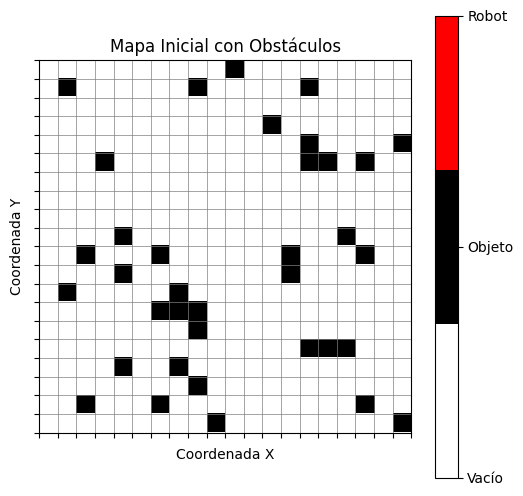

In [103]:
# Visualizar el mapa recién creado
initial_map = crear_mapa(SIZE, OBJETOS)
plt.figure(figsize=(6, 6))
plt.imshow(initial_map, cmap=cmap, vmin=0, vmax=2)
plt.title('Mapa Inicial con Obstáculos')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.colorbar(ticks=[VACIO, OBJETO, ROBOT], label='', format=plt.FuncFormatter(lambda x, p: {VACIO: 'Vacío', OBJETO: 'Objeto', ROBOT: 'Robot'}.get(x, '')))
plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
plt.xticks(np.arange(-0.5, SIZE, 1), labels=[])
plt.yticks(np.arange(-0.5, SIZE, 1), labels=[])
plt.show()

### Función `sensor_distancia`

Simula el funcionamiento de un sensor de distancia. Dada una posición inicial del robot (x, y) y una dirección (dx, dy), esta función calcula la distancia hasta el primer objeto encontrado en esa dirección o hasta el límite del mapa, lo que ocurra primero.

In [90]:
def sensor_distancia(mapa, x, y, dx, dy):
    distancia = 0
    while 0 <= x+dx < SIZE and 0 <= y+dy < SIZE:
        x += dx
        y += dy
        distancia += 1
        if mapa[x, y] == OBJETO:
            break
    return distancia

### Función `rotar`

Esta función auxiliar se encarga de rotar un vector de dirección (dx, dy) en un ángulo específico (90 o -90 grados).

In [91]:
def rotar(direccion, angulo):
    dx, dy = direccion
    if angulo == 90:
        return dy, -dx
    elif angulo == -90:
        return -dy, dx
    return dx, dy

### Función `simular_robot`

Esta es la función principal que orquesta toda la simulación. Se encarga de:

1.  **Inicializar** el mapa y la posición/dirección del robot.
2.  En cada `paso` de la simulación:
    *   **Medir** las distancias a los obstáculos y bordes utilizando los sensores.
    *   **Decidir** la acción a tomar (girar o seguir recto) basándose en las lecturas de los sensores, priorizando la evasión de obstáculos y bordes.
    *   **Actualizar** la posición del robot.
    *   **Visualizar** el estado actual del mapa, el robot, los sensores y la trayectoria, con una animación fluida.

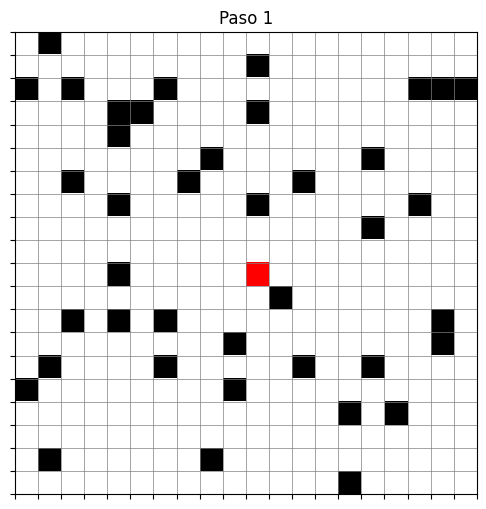

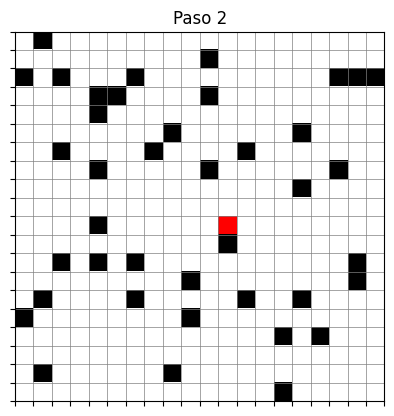

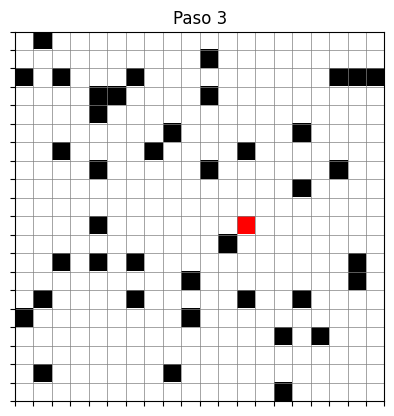

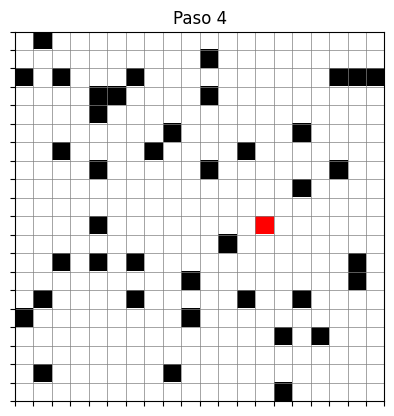

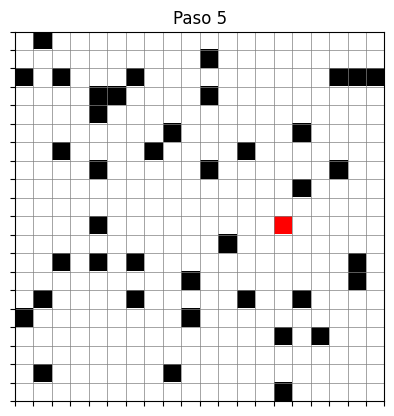

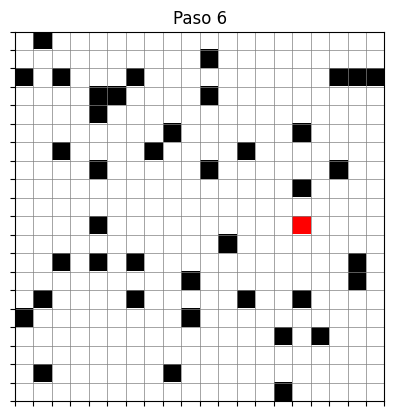

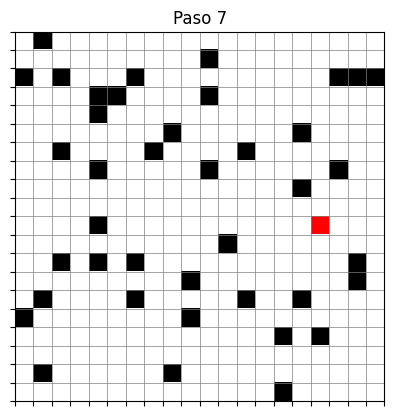

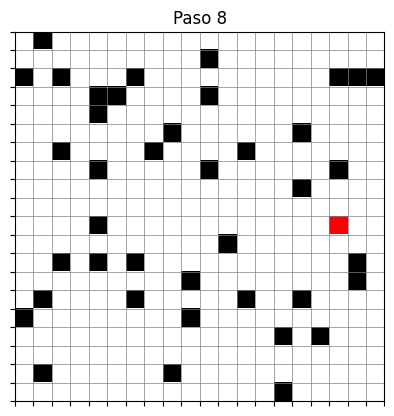

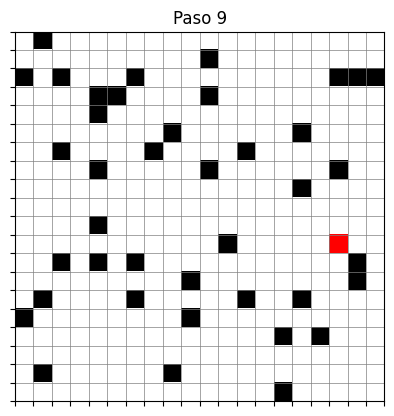

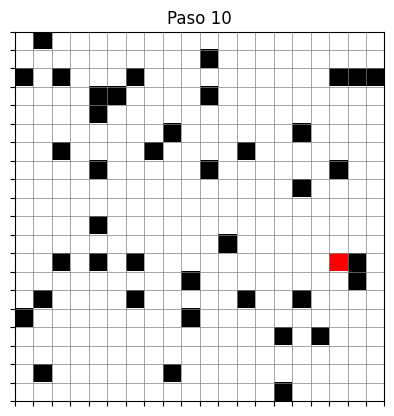

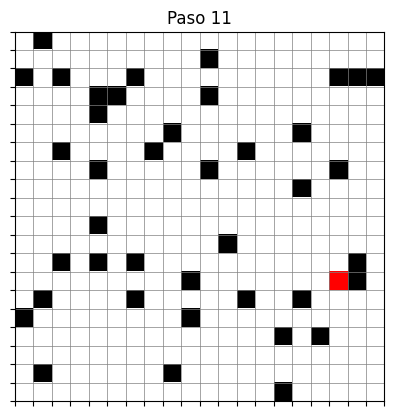

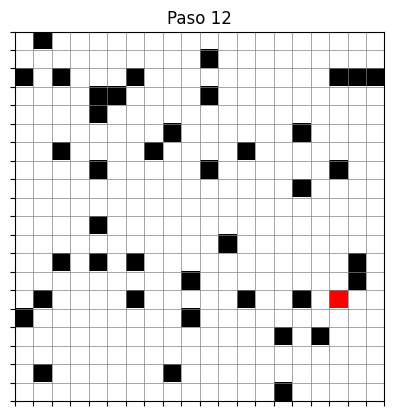

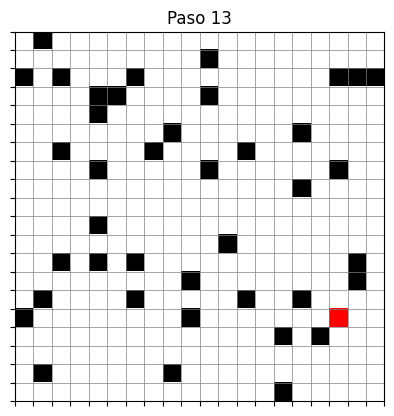

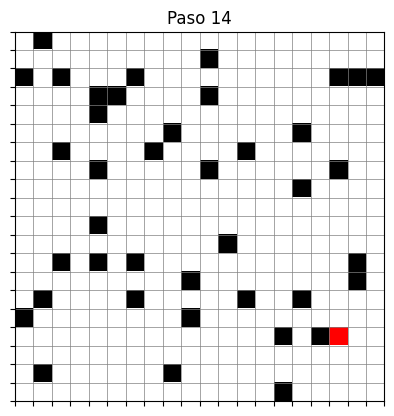

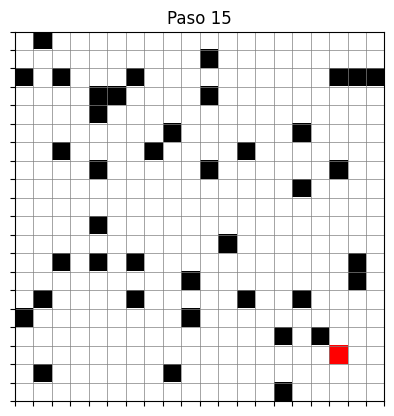

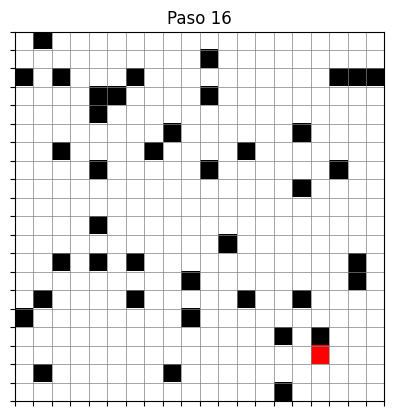

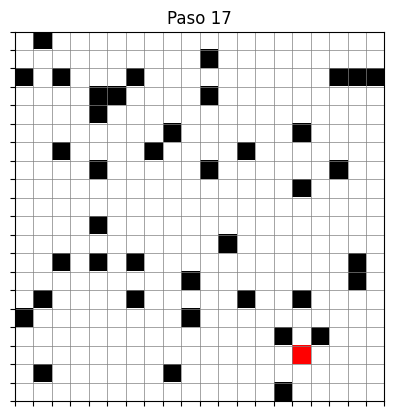

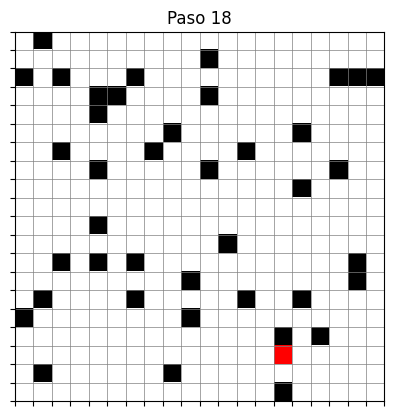

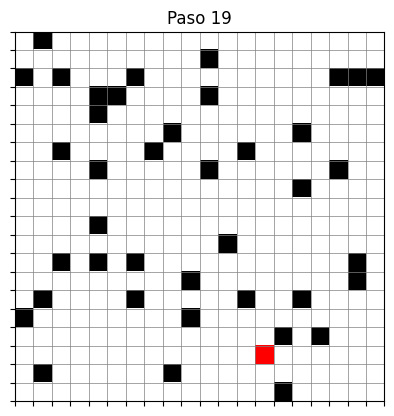

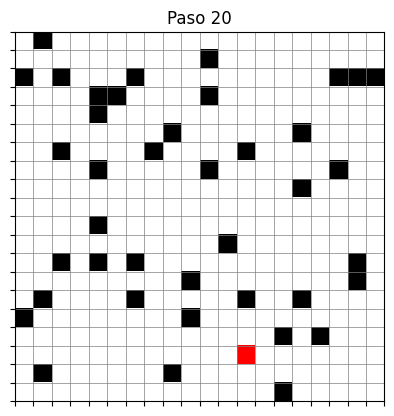

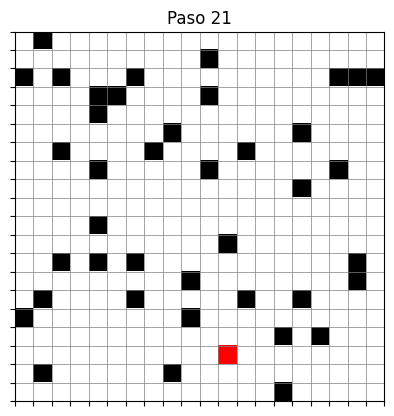

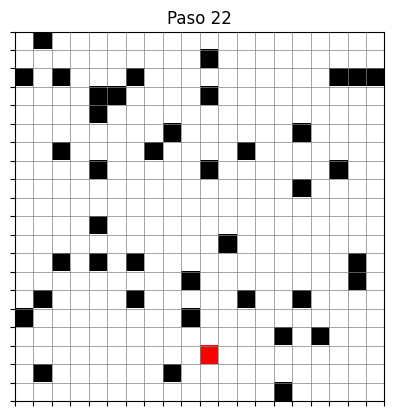

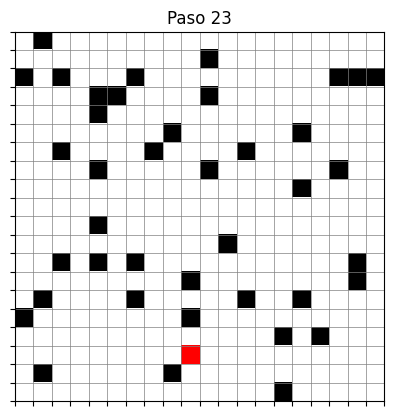

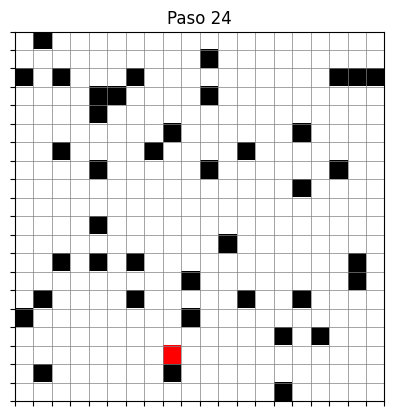

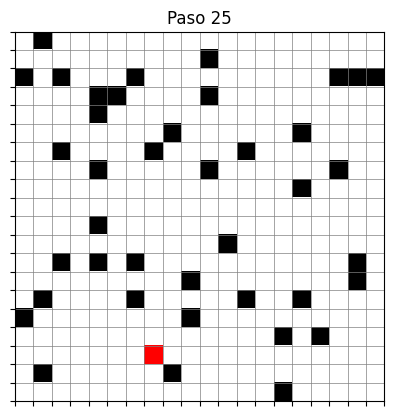

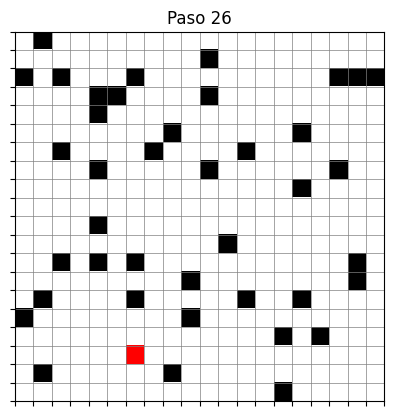

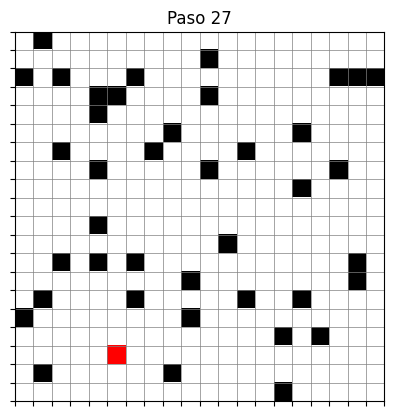

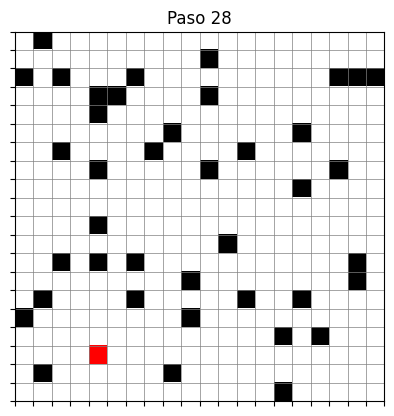

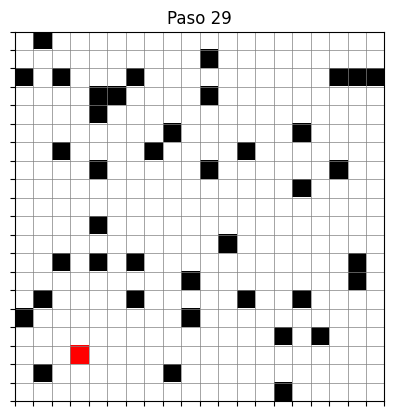

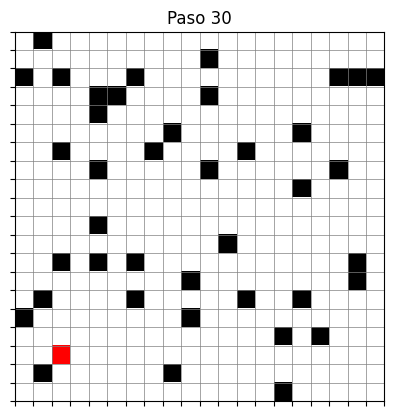

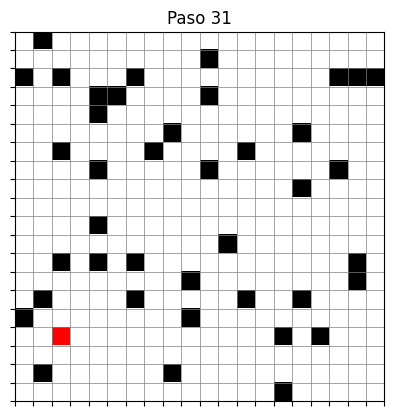

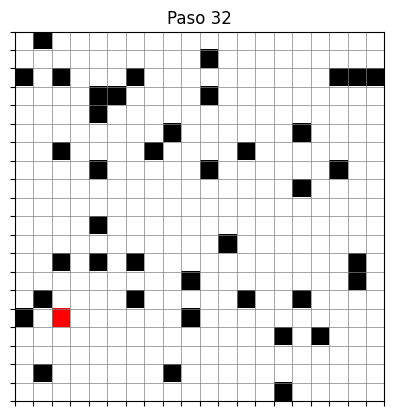

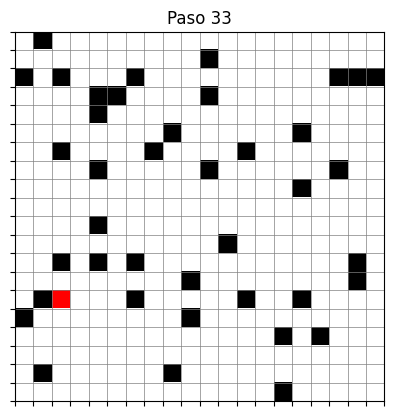

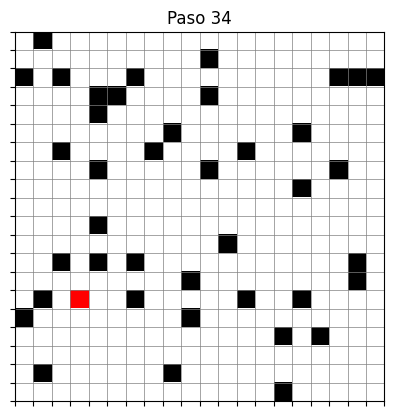

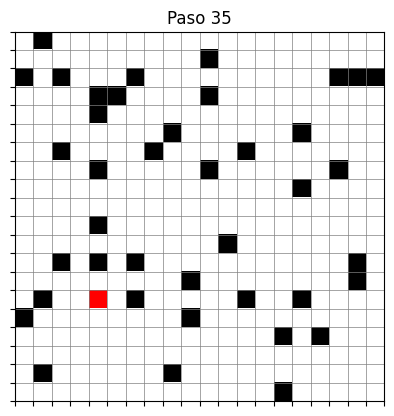

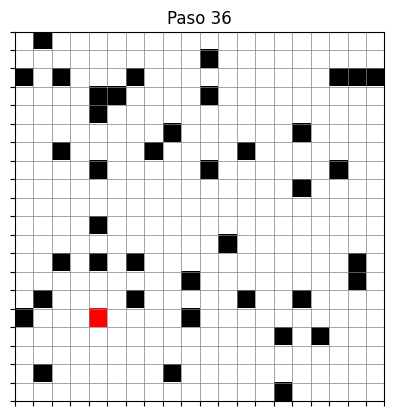

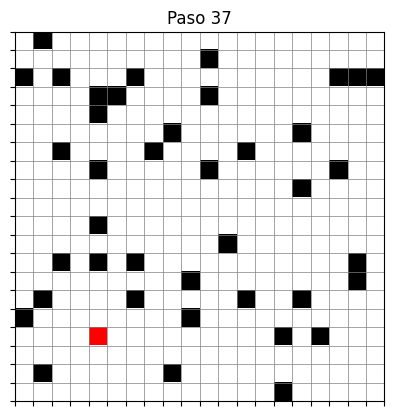

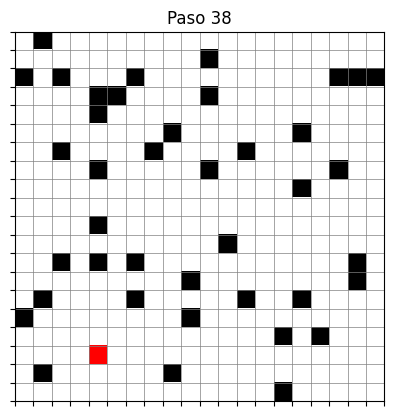

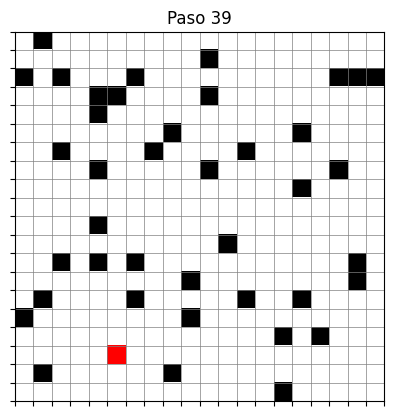

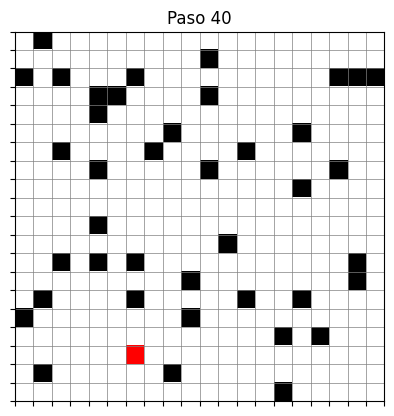

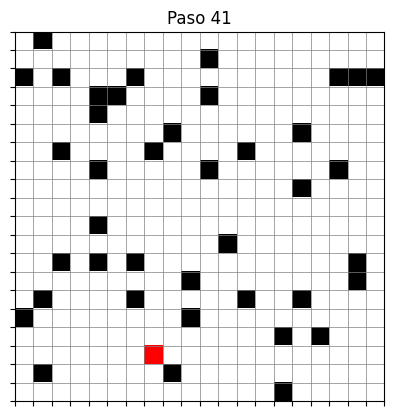

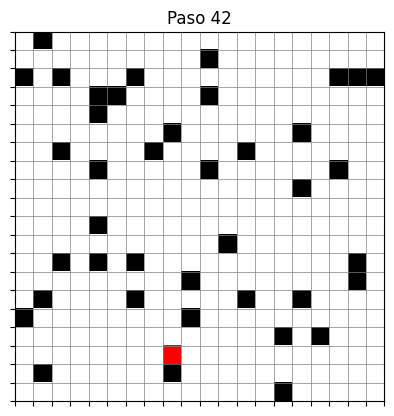

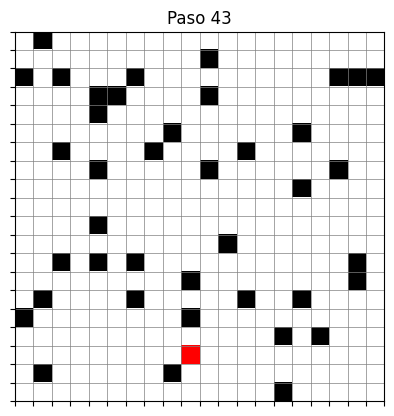

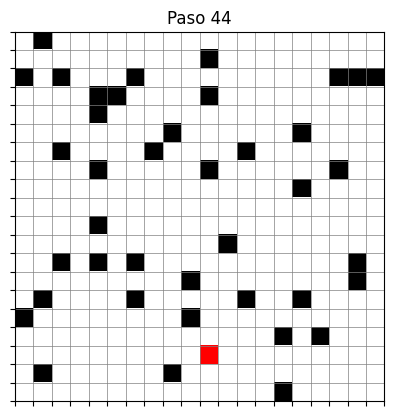

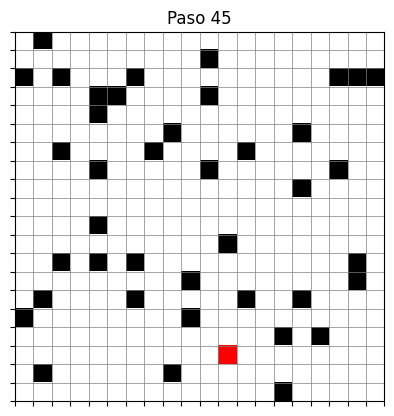

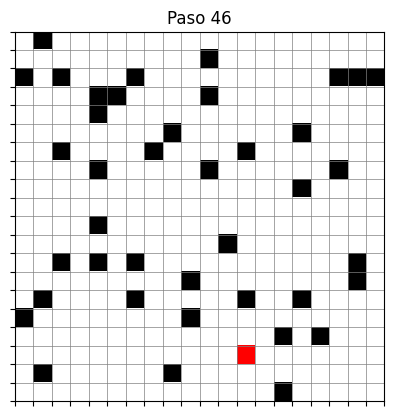

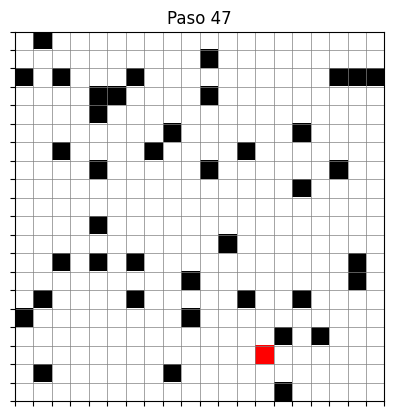

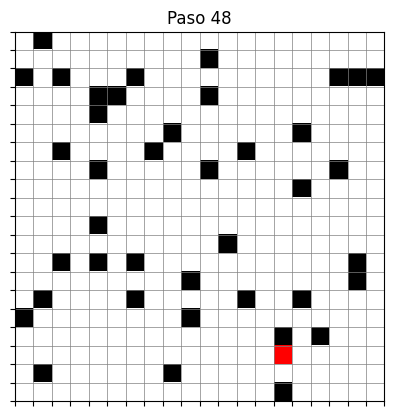

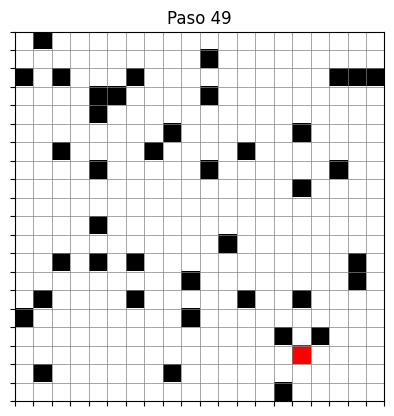

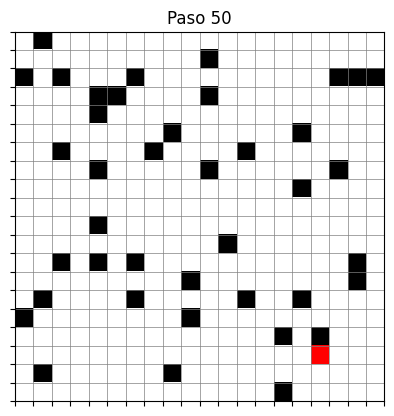

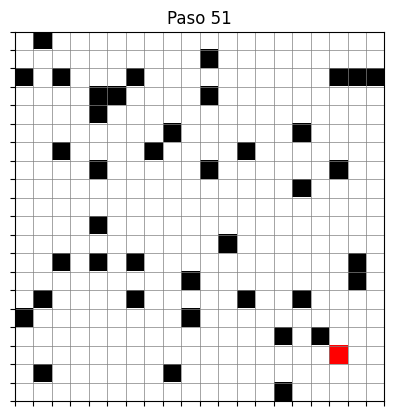

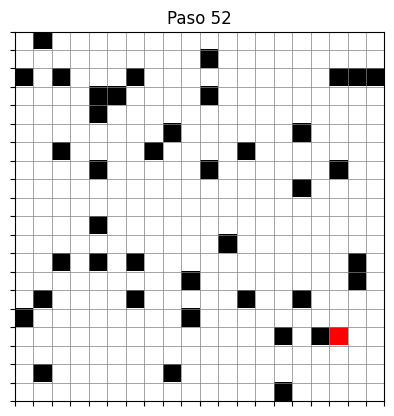

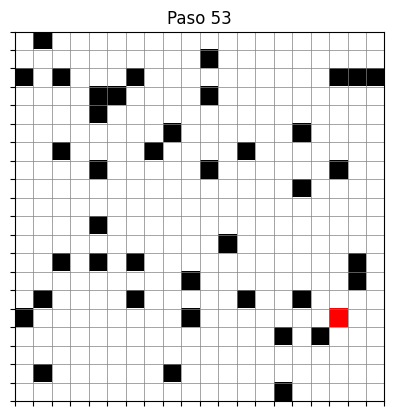

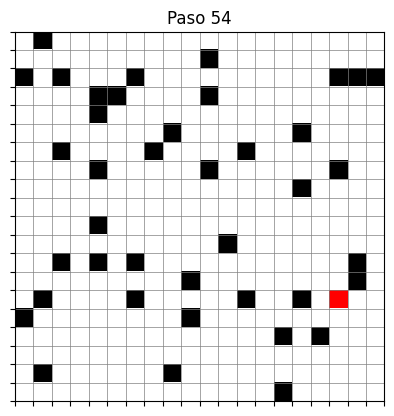

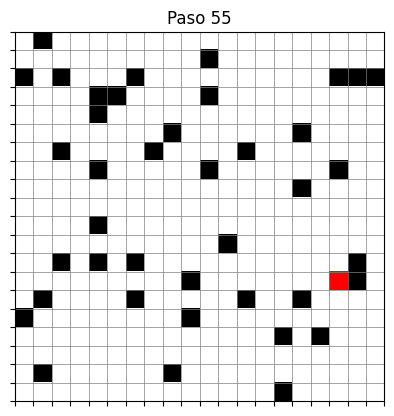

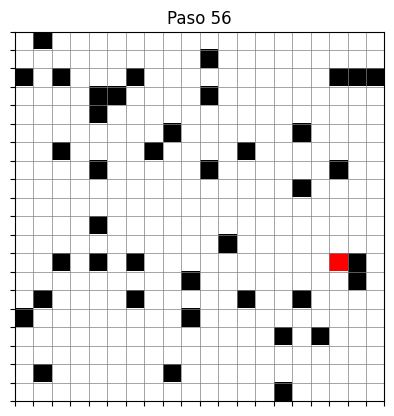

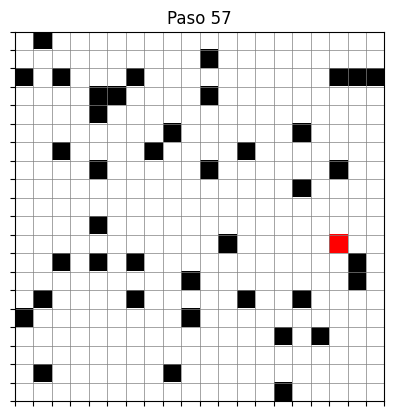

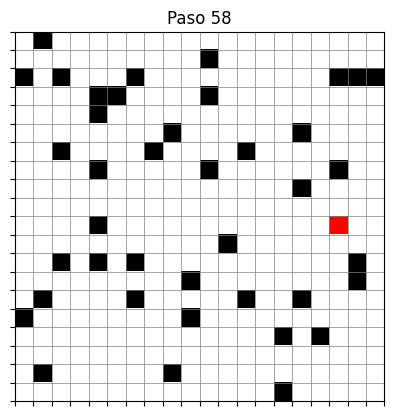

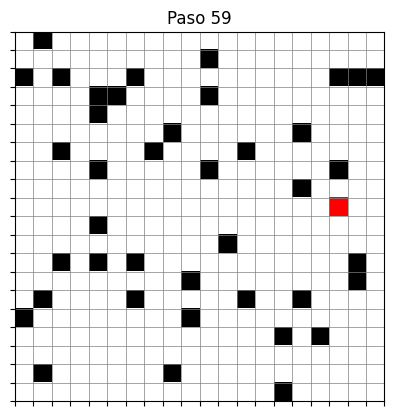

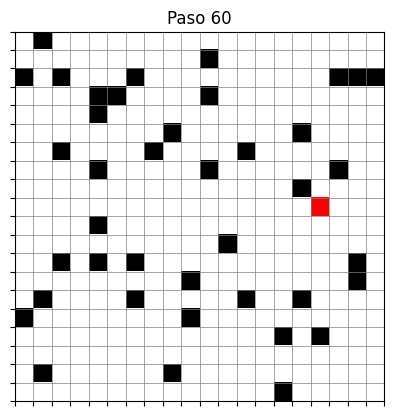

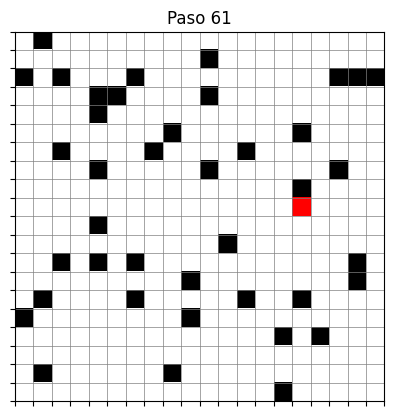

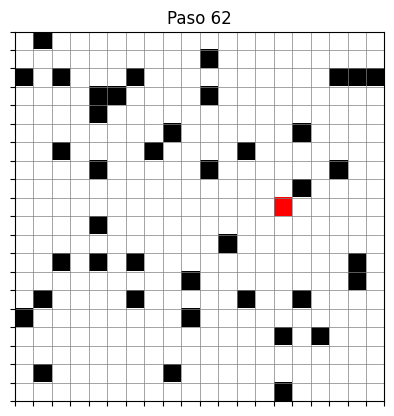

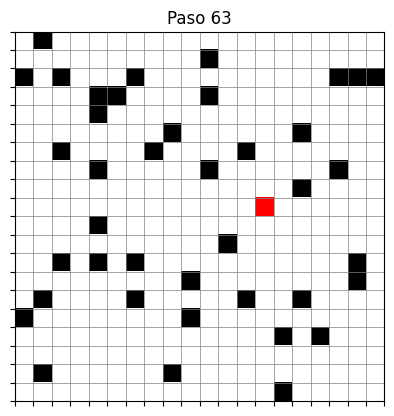

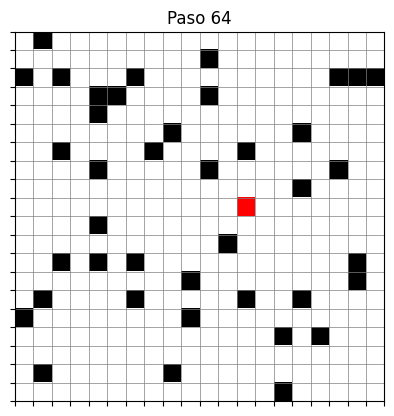

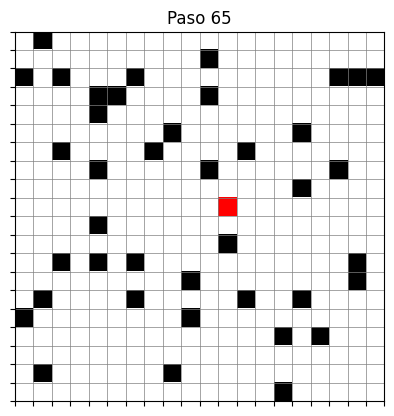

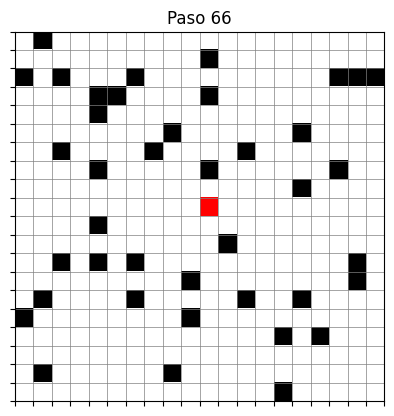

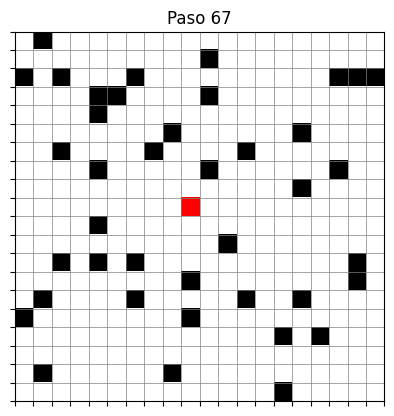

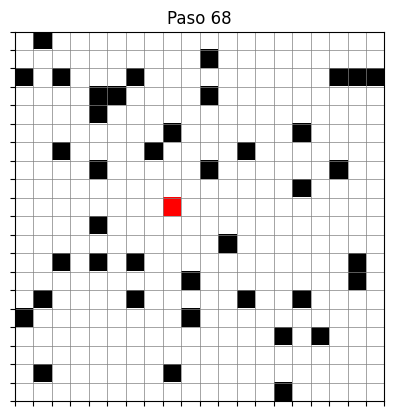

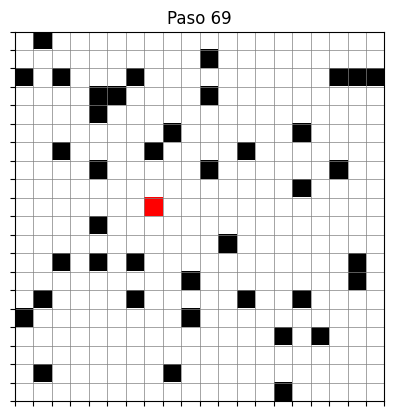

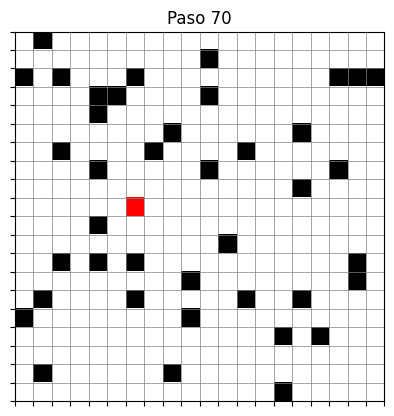

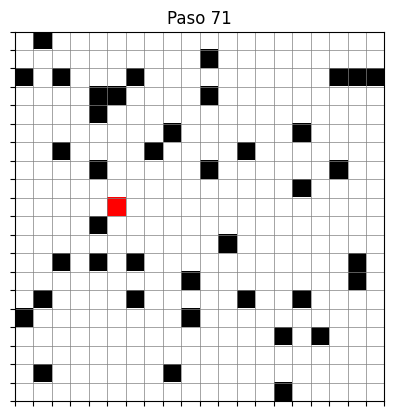

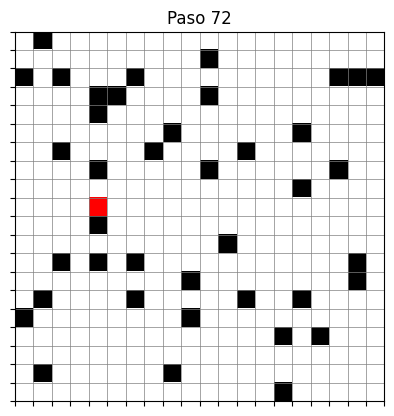

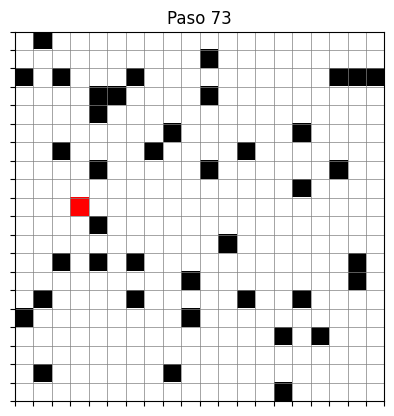

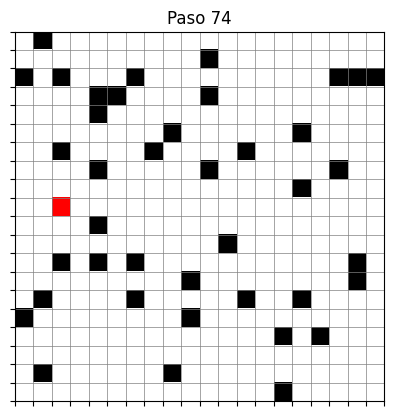

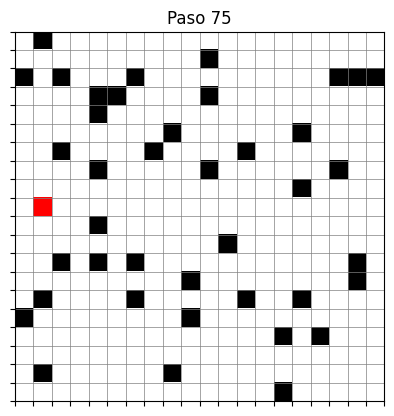

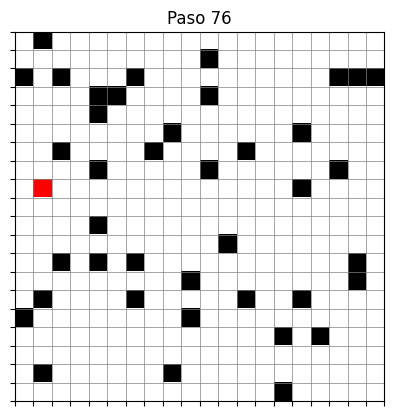

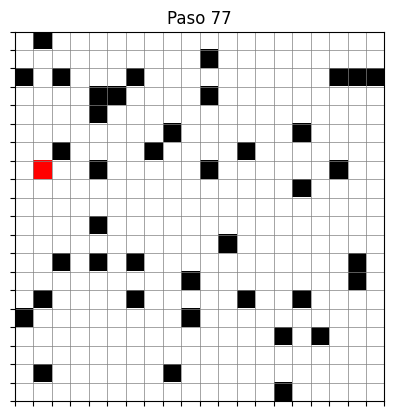

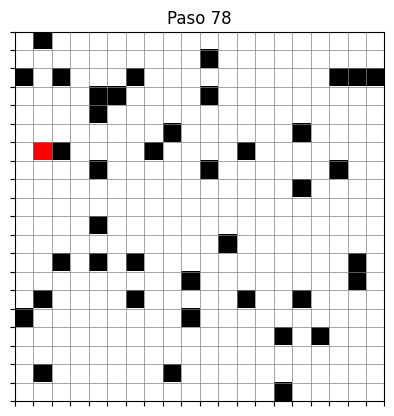

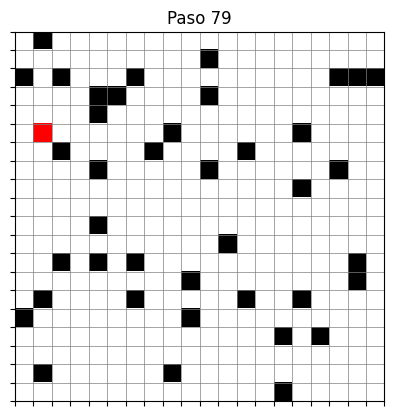

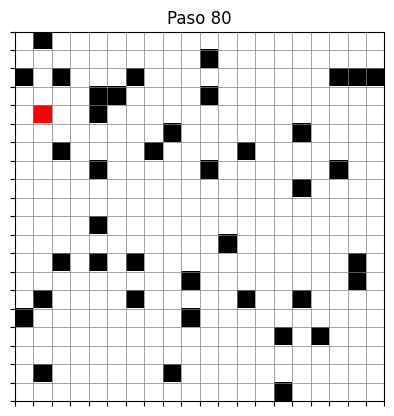

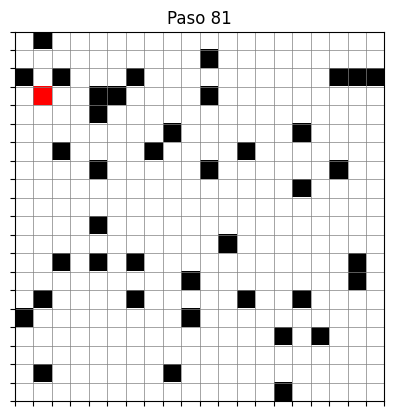

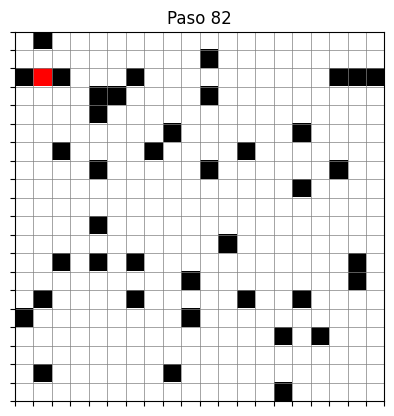

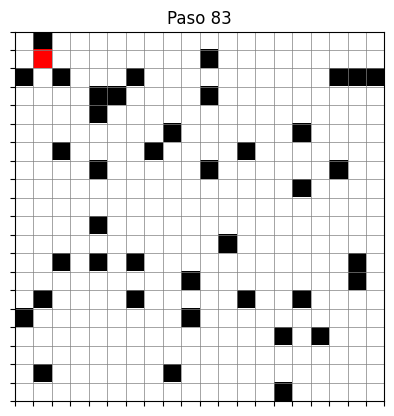

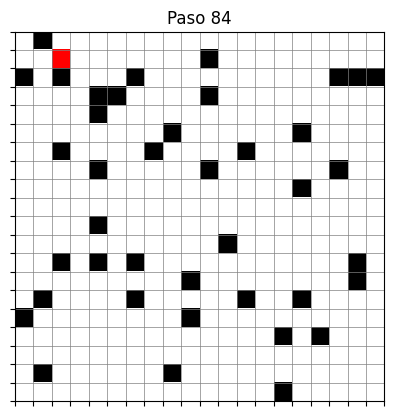

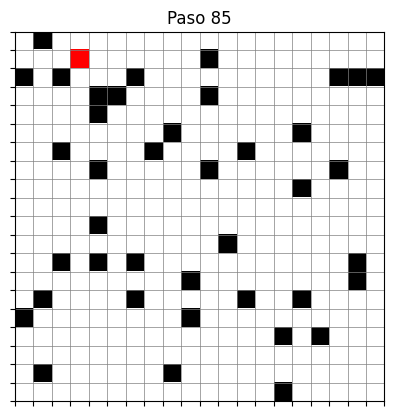

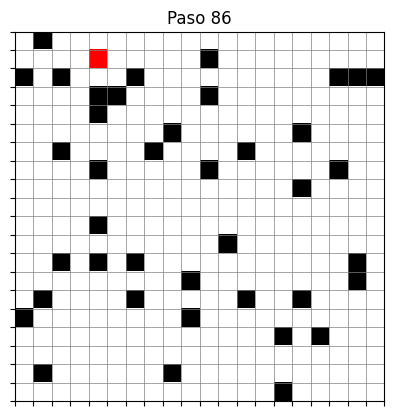

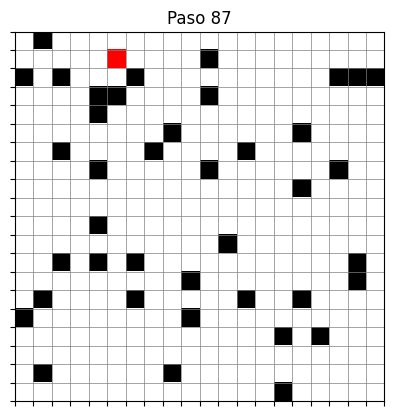

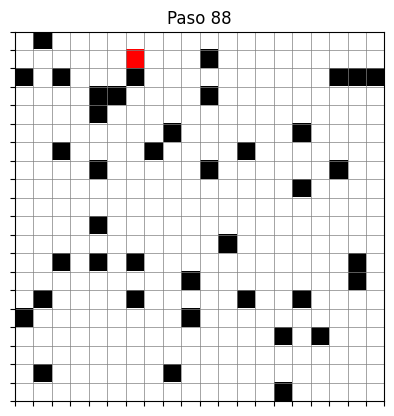

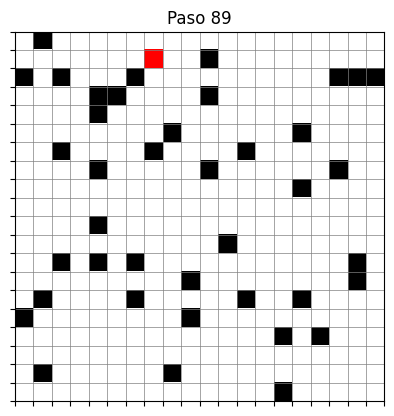

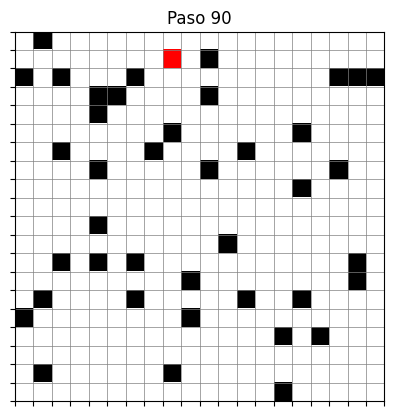

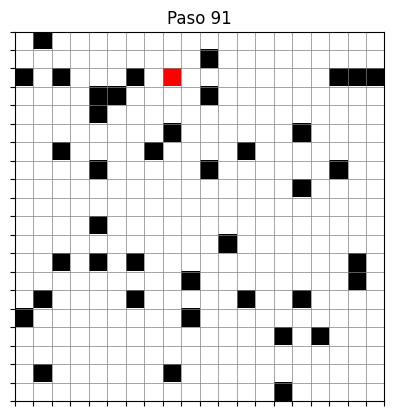

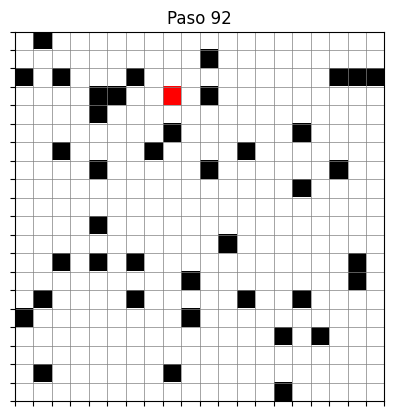

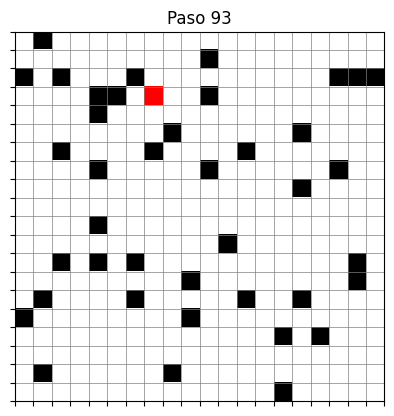

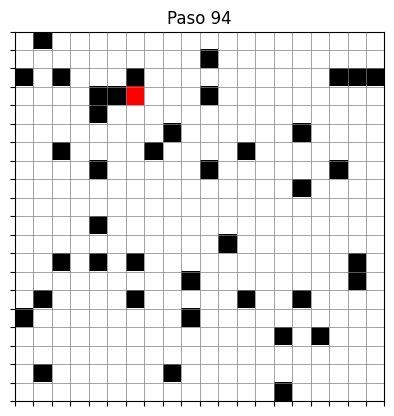

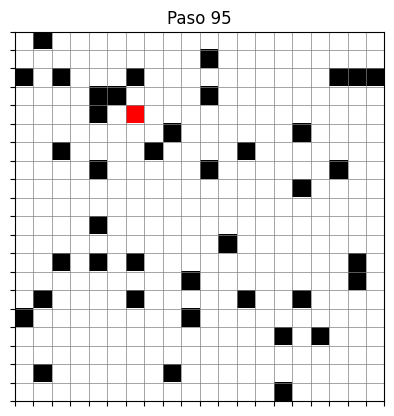

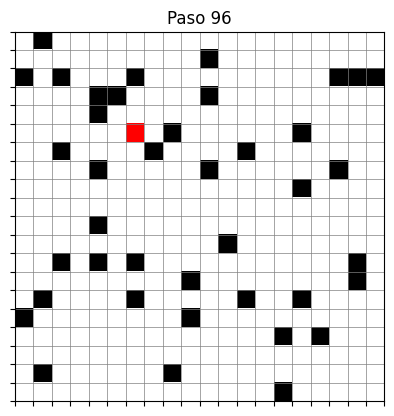

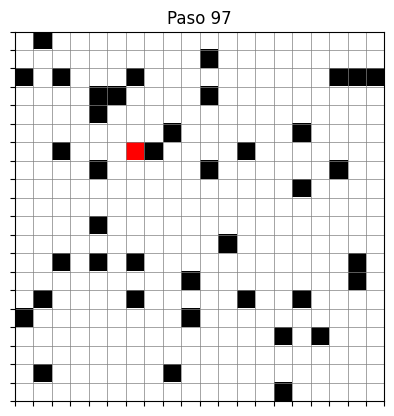

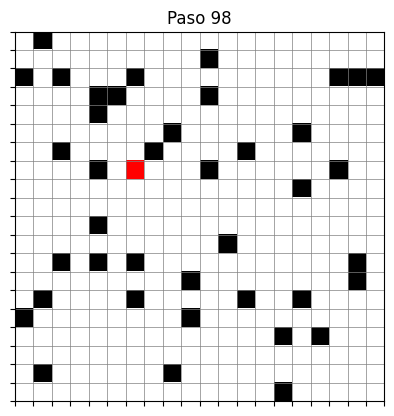

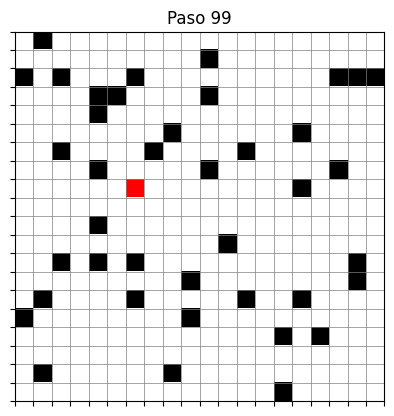

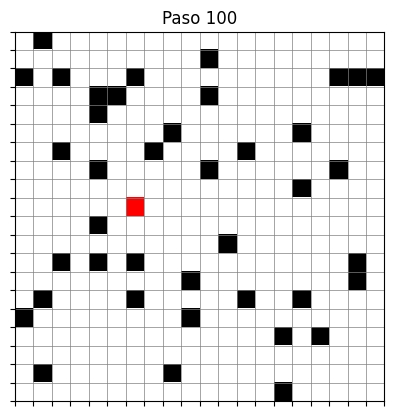

In [105]:
def simular_robot():
    mapa = crear_mapa(SIZE, OBJETOS)
    x, y = SIZE//2, SIZE//2
    direccion = (0, 1)  # inicia hacia la derecha

    plt.figure(figsize=(6, 6))


    #Ciclos de los pasos
    for paso in range(PASOS):
        mapa_temp = mapa.copy()
        mapa_temp[x, y] = ROBOT

        # Sensores: Izquierda, frente, derecha
        sensores = []
        for angulo in [-90, 0, 90]:
            dx, dy = rotar(direccion, angulo)
            sensores.append(sensor_distancia(mapa, x, y, dx, dy))

        # Decisión: evitar obstáculos antes de chocar
        # Aca van los sensores, se asume que el objeto no retrocede
        # (seria muy facil moverlo en linea recta)
        frente = sensores[1]
        izquierda = sensores[0]
        derecha = sensores[2]

        if frente <= 2:  # Si un obstáculo está muy cerca al frente
            if izquierda > derecha:
                direccion = rotar(direccion, -90)
            elif derecha > izquierda:
                direccion = rotar(direccion, 90)
            else:
                # Si ambos lados están bloqueados, retrocedemos
                direccion = rotar(direccion, 180 if random.random() > 0.5 else -180)

        # Mover robot si hay espacio
        dx, dy = direccion
        if 0 <= x+dx < SIZE and 0 <= y+dy < SIZE and mapa[x+dx, y+dy] != OBJETO:
            x += dx
            y += dy
        else:
            # Si no hay espacio, giramos aleatoriamente
            direccion = rotar(direccion, 90 if random.random() > 0.5 else -90)

        # Visualización
        plt.clf()
        plt.imshow(mapa_temp, cmap=cmap, vmin=0, vmax=2)
        plt.title(f"Paso {paso+1}")
        plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
        plt.xticks(np.arange(-0.5, SIZE, 1), labels=[])
        plt.yticks(np.arange(-0.5, SIZE, 1), labels=[])
        plt.pause(0.25)

    plt.show()

# Ejecutar simulación
simular_robot()